In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_raw.xlsx to dataset_raw.xlsx


In [2]:
print(uploaded.keys())

dict_keys(['dataset_raw.xlsx'])


In [4]:
import pandas as pd
df = pd.read_excel('dataset_raw.xlsx', engine='openpyxl')
print(df.shape)
print(df.columns.tolist())

(51290, 24)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [5]:
df['Profit Margin'] = df['Profit'] / df['Sales']
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Sales', 'Profit', 'Profit Margin', 'Shipping Delay']].head())

      Sales    Profit  Profit Margin  Shipping Delay
0  2309.650  762.1845       0.330000               0
1  3709.395 -288.7650      -0.077847               2
2  5175.171  919.9710       0.177766               1
3  2892.510  -96.5400      -0.033376               2
4  2832.960  311.5200       0.109963               1


/tmp/ipykernel_884/523600784.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_884/523600784.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Segment_encoded'] = le.fit_transform(df['Segment'])
df['Category_encoded'] = le.fit_transform(df['Category'])
df['Region_encoded'] = le.fit_transform(df['Region'])

print(df[['Segment', 'Segment_encoded', 'Category', 'Category_encoded']].head())

       Segment  Segment_encoded    Category  Category_encoded
0     Consumer                0  Technology                 2
1    Corporate                1   Furniture                 0
2     Consumer                0  Technology                 2
3  Home Office                2  Technology                 2
4     Consumer                0  Technology                 2


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df['Target'] = (df['Profit'] > 0).astype(int)

features = ['Sales', 'Quantity', 'Discount', 'Shipping Cost',
            'Segment_encoded', 'Category_encoded',
            'Region_encoded', 'Shipping Delay']

X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      2696
           1       0.92      0.96      0.94      7562

    accuracy                           0.91     10258
   macro avg       0.90      0.87      0.88     10258
weighted avg       0.91      0.91      0.91     10258



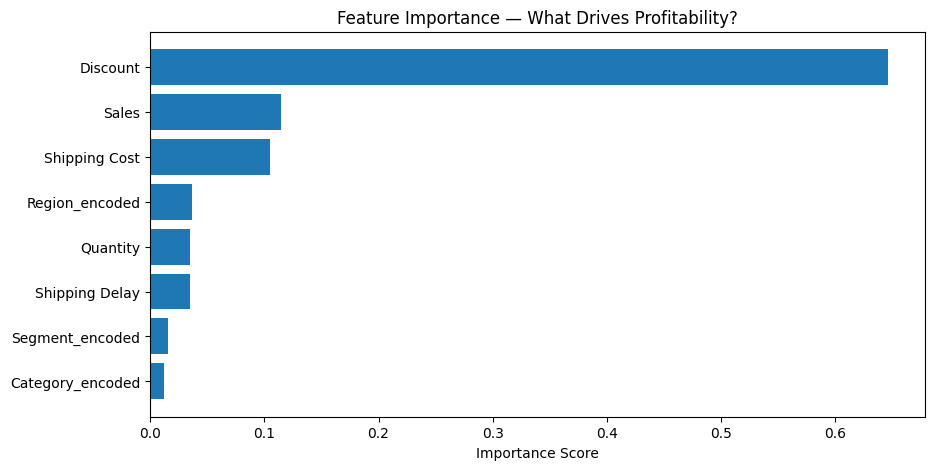

            Feature  Importance
2          Discount    0.646209
0             Sales    0.114816
3     Shipping Cost    0.104869
6    Region_encoded    0.036619
1          Quantity    0.035238
7    Shipping Delay    0.034584
4   Segment_encoded    0.015875
5  Category_encoded    0.011790


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title('Feature Importance — What Drives Profitability?')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print(importance_df)

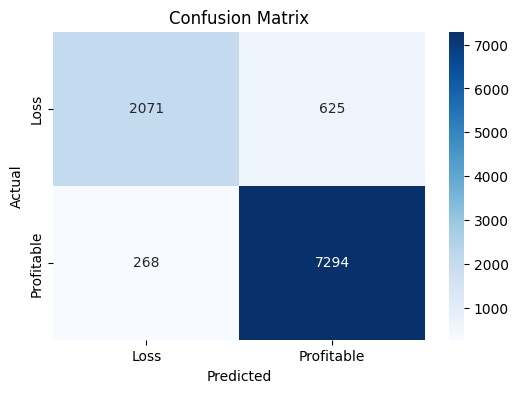

In [9]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Profitable'],
            yticklabels=['Loss', 'Profitable'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [10]:
import joblib

joblib.dump(model, 'superstore_model.pkl')
print("Model saved successfully!")

Model saved successfully!
